# 08_get_binding_pocket_properties

Notebook for extracting binding-pocket properties with or without an explicit ligand.


## Python Path Setup


In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "notebooks" else cwd
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_root = repo_root / "src"
if src_root.exists() and str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))


## Imports


In [2]:
import importlib
import pandas as pd

import agentic_protein_design.steps.get_binding_pocket_properties as pocket_script
pocket_script = importlib.reload(pocket_script)

default_user_inputs = pocket_script.default_user_inputs
run_binding_pocket_property_extraction = pocket_script.run_binding_pocket_property_extraction


## Workflow Skeleton

1. Choose whether a ligand is present.
2. Run either `PocketAnalysis` or `LigandPocketAnalysis` from `tools/struct/`.
3. Inspect the generated binding-pocket property tables.


## User Inputs (Edit This Cell)


In [3]:
user_inputs = default_user_inputs()

# Data root key from project_config/variables.py (address_dict)
user_inputs["root_key"] = 'ECOHARVEST' # "examples"
user_inputs["data_subfolder"] = "lipases"

# Set True to use LigandPocketAnalysis, False to use PocketAnalysis
user_inputs["ligand_present"] = True

# Shared analysis settings
user_inputs["protein_molname"] = "A"
user_inputs["plot_properties"] = False
user_inputs["struct_csv_subdirectory_name"] = "structure_csv"

# Ligand-aware settings (used when ligand_present = True)
user_inputs["ligand_molname"] = "B"
user_inputs["dist_thres"] = 8
user_inputs["reactive_center_target"] = [
    {"enz":'RML', "protein":[144,203,257], "ligand":'O2'},
    {"enz":'TLL', "protein":[146,201,258], "ligand":'O2'}
]
user_inputs["keep_pos_with_aa_variation_only"] = False
user_inputs["analyse_binding_pocket_without_ligand"] = True
user_inputs["seq_align_fname"] = 'RML_TLL_ali.fasta' # "UPO_peroxygenation_ali.fasta"
user_inputs["binding_pocket_residues_fname"] = "residues_near_ligand.csv"
user_inputs["struct_dict"] = {
    # lipases
    "RML": 'RML_SucroseOleate',
    "TLL": "TLL_SucroseOleate",
    # "CALB": "CALB_SucroseOleate",
    # "CALA": "CALA_SucroseOleate",
    # # UPOs
    # "ET096": "ET096_S82",
    # "CviUPO": "CviUPO_S82",
    # "DcaUPO": "DcaUPO_S82",
    # "TE314": "TE314_S82",
    # "OA167": "OA167_S82",
}

# Ligand-free settings (used when ligand_present = False)
# pocket_residues_source = "csv": load {root}/pdb/{data_subfolder}/binding_pocket_residues_fname
# pocket_residues_source = "inline": use pocket_residues_dict below
user_inputs["pocket_residues_source"] = "csv"
user_inputs["pocket_residues_dict"] = {
    # "ET096": [69, 73, 158],
    # "CviUPO": [69, 73, 158],
}

user_inputs


{'root_key': 'ECOHARVEST',
 'data_subfolder': 'lipases',
 'ligand_present': True,
 'protein_molname': 'A',
 'ligand_molname': 'B',
 'dist_thres': 8,
 'reactive_center_target': [{'enz': 'RML',
   'protein': [144, 203, 257],
   'ligand': 'O2'},
  {'enz': 'TLL', 'protein': [146, 201, 258], 'ligand': 'O2'}],
 'keep_pos_with_aa_variation_only': False,
 'plot_properties': False,
 'analyse_binding_pocket_without_ligand': True,
 'seq_align_fname': 'RML_TLL_ali.fasta',
 'binding_pocket_residues_fname': 'residues_near_ligand.csv',
 'struct_csv_subdirectory_name': 'structure_csv',
 'pocket_residues_source': 'csv',
 'pocket_residues_dict': {},
 'struct_dict': {'RML': 'RML_SucroseOleate', 'TLL': 'TLL_SucroseOleate'}}

## Run Binding Pocket Property Extraction


struct_fpaths: 2
[PosixPath('/Users/charmainechia/Documents/projects/ECOHARVEST/pdb/lipases/RML_SucroseOleate.pdb'), PosixPath('/Users/charmainechia/Documents/projects/ECOHARVEST/pdb/lipases/TLL_SucroseOleate.pdb')]
Ref Object: RML_SucroseOleate.pdb (269 residues) 

TLL_SucroseOleate.pdb (269 residues)
TM-align score: None
RMSD (superposed residues): 0
RMSD (aligned residues): 1.44
# of aligned residues: 231/269 (85.9%)
[IDENTICAL] all: 76 (32.9%); hydrophobic: 34 (14.7%); non-hydrophobic: 42 (18.2%)
[SIMILAR] all: 132 (57.1%); hydrophobic: 68 (29.4%); non-hydrophobic: 64 (27.7%)

struct_fpaths: 2 [PosixPath('/Users/charmainechia/Documents/projects/ECOHARVEST/pdb/lipases/RML_SucroseOleate.pdb'), PosixPath('/Users/charmainechia/Documents/projects/ECOHARVEST/pdb/lipases/TLL_SucroseOleate.pdb')]
Saved SCE output: /Users/charmainechia/Documents/projects/ECOHARVEST/sce/lipases/RML_TLL_ali.sce
num_obj: 2
Saved PDB output: /Users/charmainechia/Documents/projects/ECOHARVEST/pdb/lipases/RML_Suc

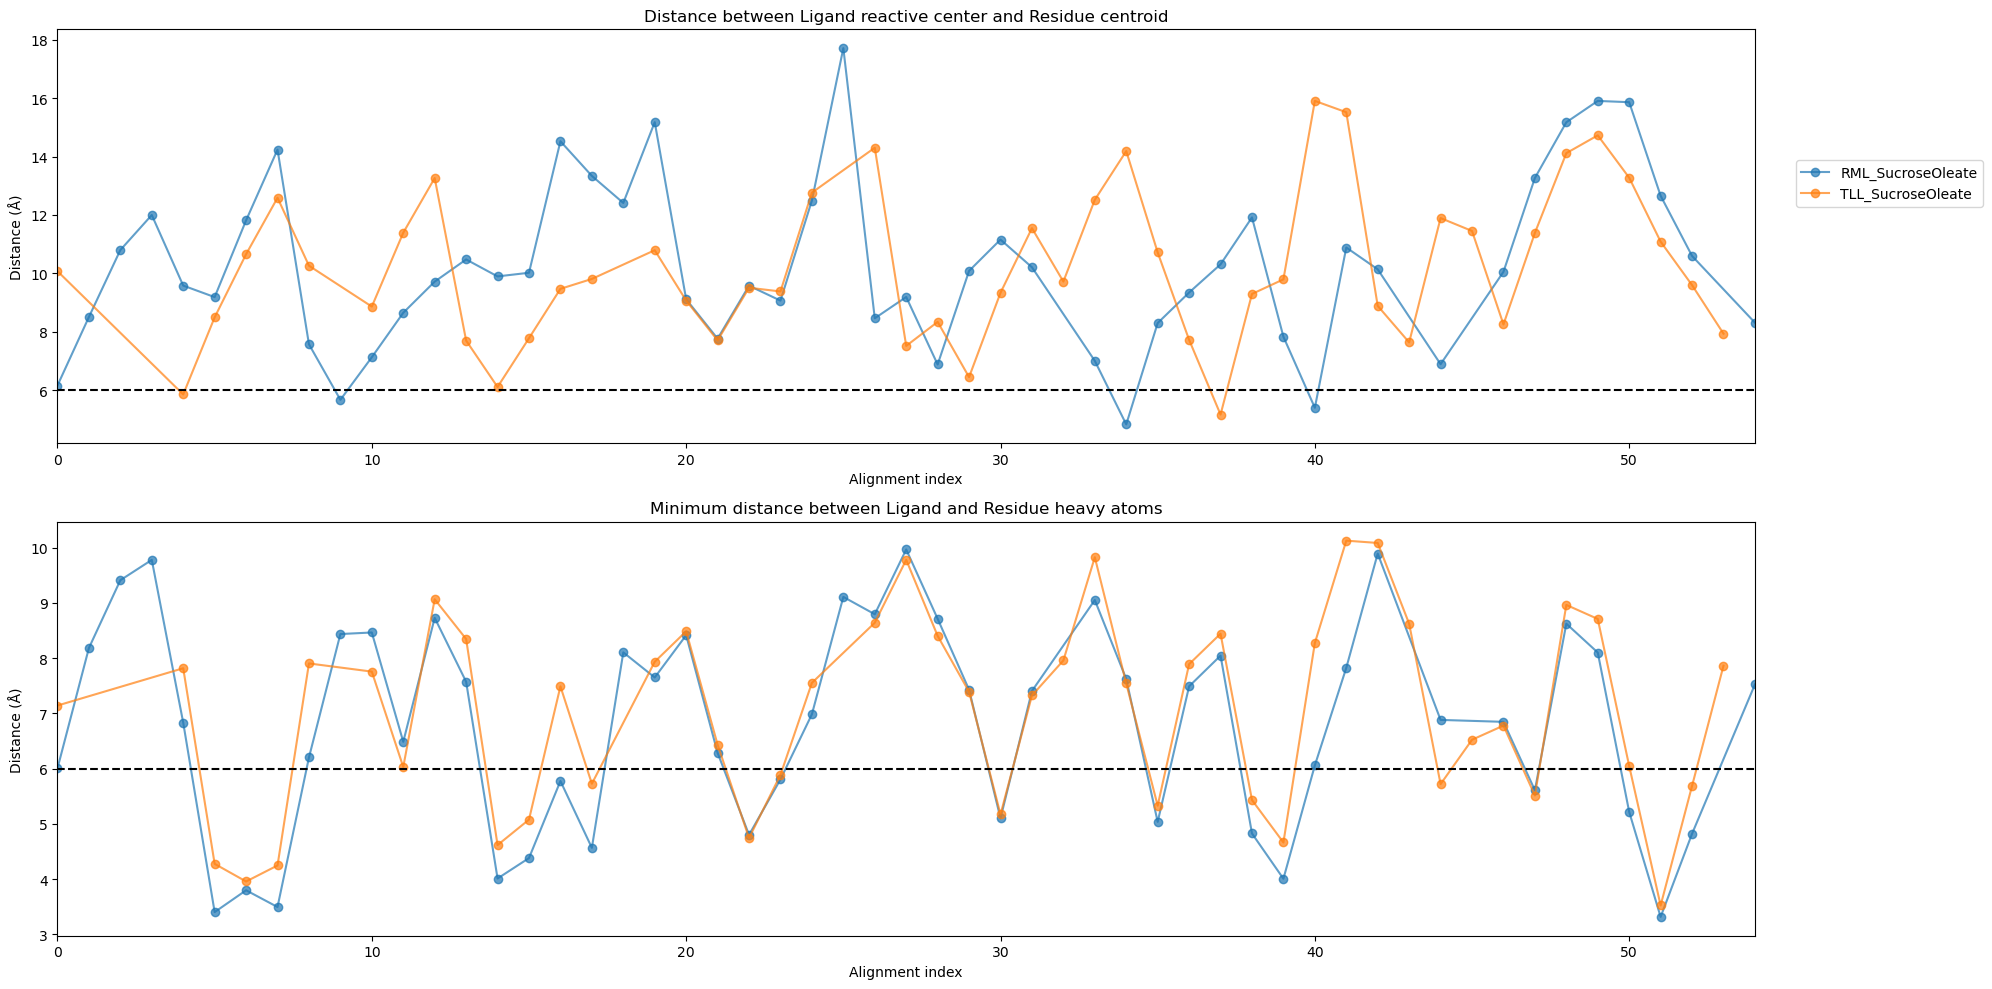

  1 29 28Y 21Y 6.007 7.143
  2 97 80R 81R 6.833 7.818
  3 98 81G 82G 3.405 4.278
  4 99 82S 83S 3.8 3.959
* 5 100 83S 84R 3.497 4.249
  6 101 84S 85S 6.203 7.905
  7 105 88W 89W 6.487 6.031
* 8 108 91D 92N 4.013 4.618
  9 109 92L 93L 4.383 5.079
* 10 110 93T 94N 5.777 7.49
  11 111 94F 95F 4.568 5.728
  12 126 108H 110H 7.651 7.935
  13 161 143H 145H 6.287 6.435
  14 162 144S 146S 4.802 4.746
  15 163 145L 147L 5.807 5.888
  16 164 146G 148G 6.985 7.553
* 17 199 176Q 173A 7.428 7.392
  18 200 177P 174P 5.103 5.172
  19 201 178R 175R 7.406 7.325
  20 228 204I 202I 7.623 7.542
  21 229 205V 203V 5.038 5.331
  22 230 206P 204P 7.491 7.892
  23 232 208L 206L 4.828 5.433
  24 233 209P 207P 4.009 4.665
* 25 290 254V 255I 6.883 5.721
  26 293 257H 258H 6.848 6.78
  27 294 258L 259L 5.61 5.515
* 28 301 265T 265I 5.218 6.049
  29 302 266G 266G 3.318 3.525
* 30 303 267L 267T 4.823 5.689
Filtered alignment index (30): [28, 96, 97, 98, 99, 100, 104, 107, 108, 109, 110, 125, 160, 161, 162, 163, 198

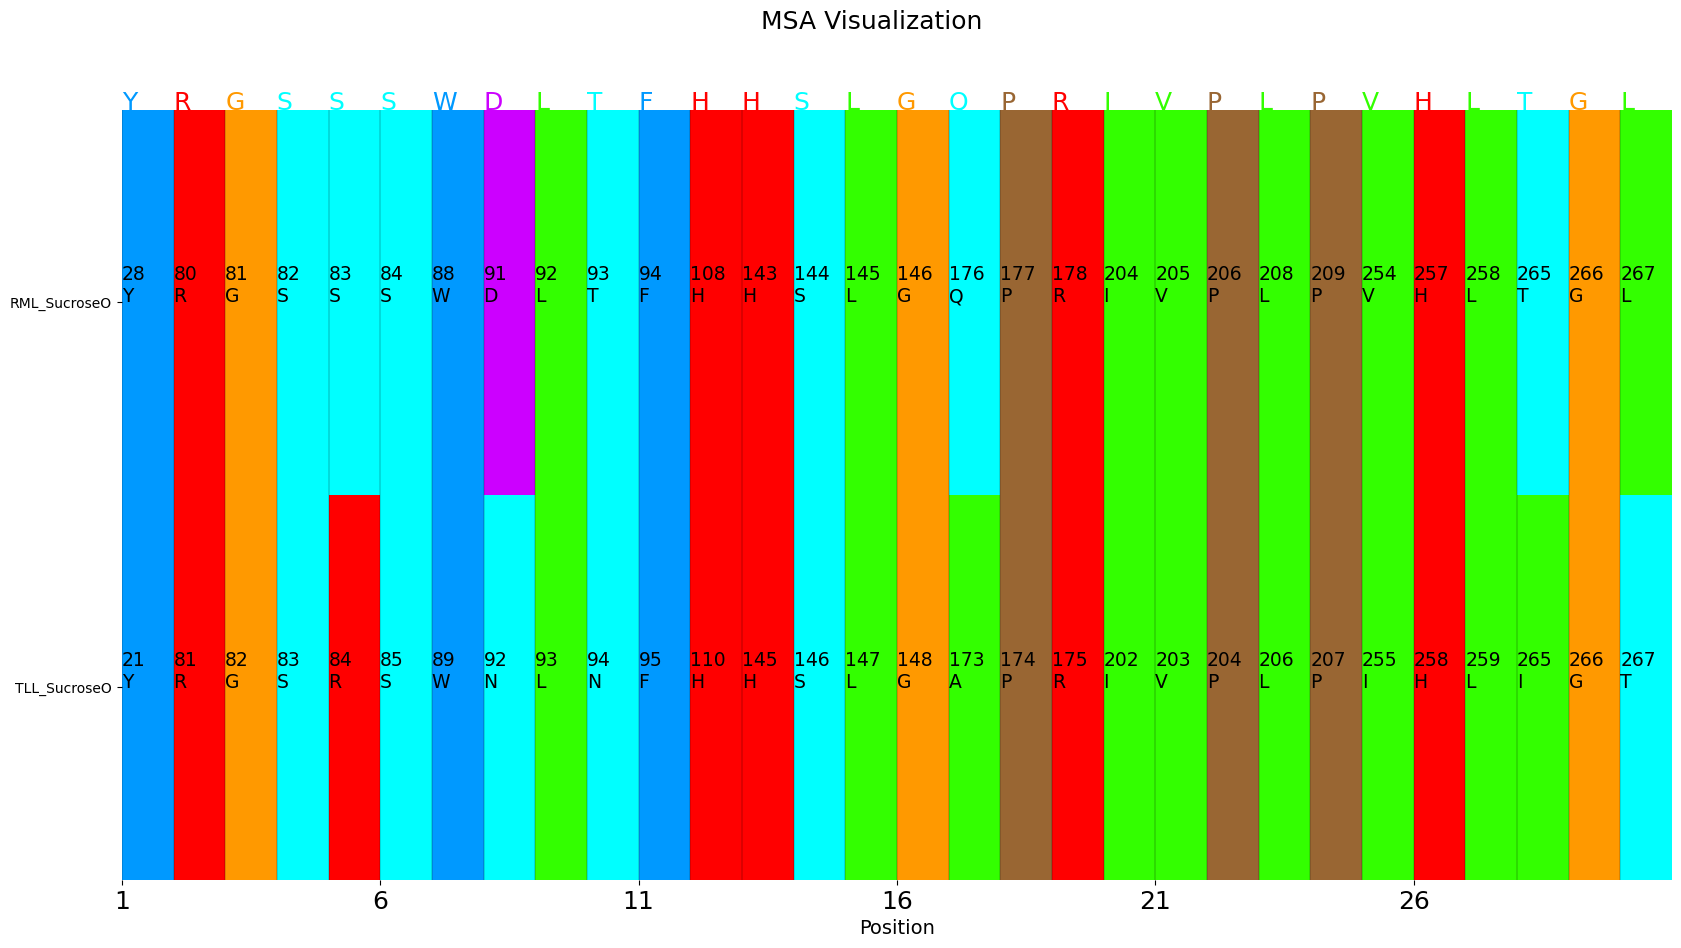

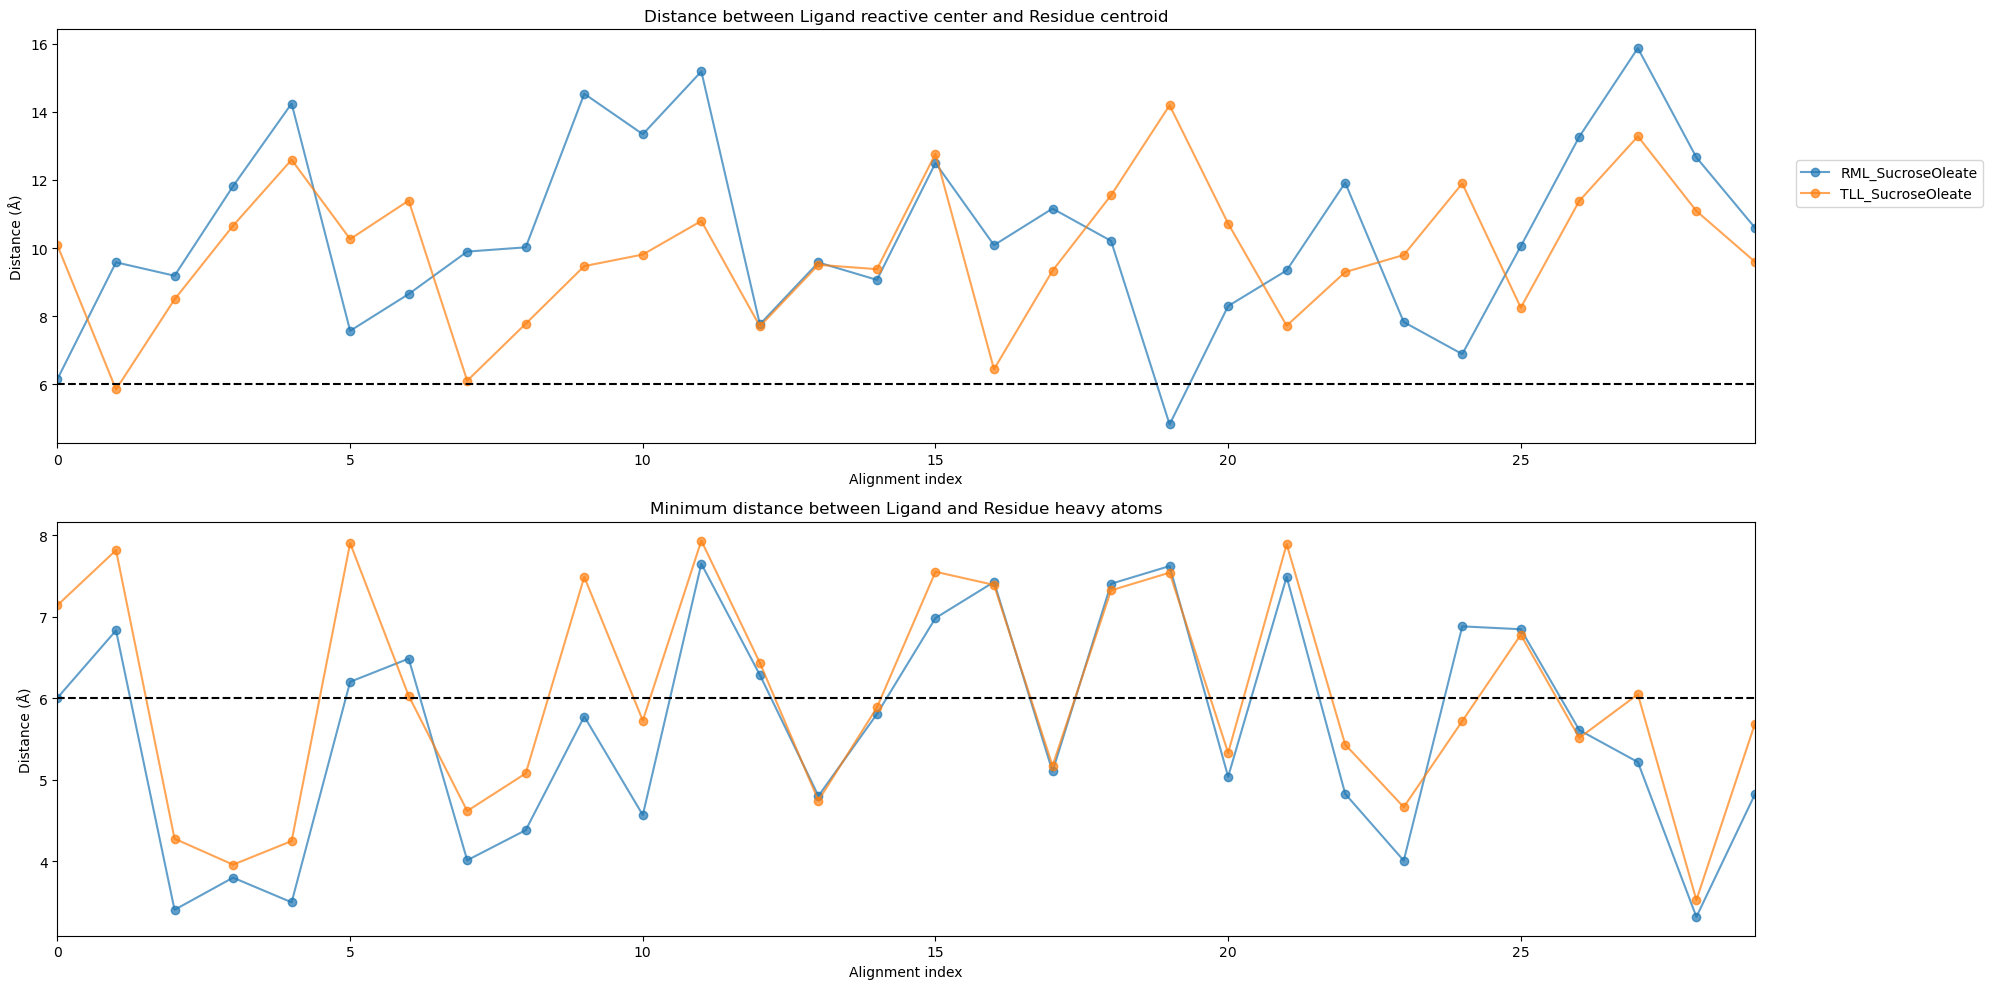

Saved all aligned proteins to YASARA scene: /Users/charmainechia/Documents/projects/ECOHARVEST/sce/lipases/RML_TLL_ali.sce
Saved RML to YASARA scene.
Saved TLL to YASARA scene.
Obtaining distal pocket properties...
Parsed 2125 atoms
Saved CSV to: /Users/charmainechia/Documents/projects/ECOHARVEST/pdb/lipases/structure_csv/RML_SucroseOleate.csv
[RML_SucroseOleate] Binding pocket residues (50): [28, 29, 30, 79, 80, 81, 82, 83, 84, 85, 87, 88, 89, 90, 91, 92, 93, 94, 95, 108, 111, 143, 144, 145, 146, 147, 148, 174, 175, 176, 177, 178, 203, 205, 206, 207, 208, 209, 210, 213, 215, 254, 257, 258, 259, 264, 265, 266, 267, 268]
Centroid: [ 7.4652481   4.4620962  -1.23186076]
--- All Residue Atoms ---
Mean distance to binding pocket centroid: 10.5172
Mean MIN distance to binding pocket centroid: 8.645
--- Backbone Only ---
Mean distance to binding pocket centroid: 10.253
Mean MIN distance to binding pocket centroid: None

Parsed 2105 atoms
Saved CSV to: /Users/charmainechia/Documents/projects/E

In [4]:
result = run_binding_pocket_property_extraction(user_inputs)
print("status:", result.get("status", ""))
print("ligand_present:", result.get("ligand_present", ""))
print("combined_analysis_path:", result.get("combined_analysis_path", ""))
